# **DAY 6 — MACHINE LEARNING BASICS**

<br>
<br>

### **PART 1 - The ML Workflow**

1. **Collect Data**: Gathering raw information from various sources like databases, APIs, or CSV files.
2. **Clean Data**: Handling missing values, removing duplicates, and fixing inconsistencies. *"Garbage in, garbage out."*
3. **Feature Engineering**: Selecting and transforming variables (features) to help the model learn better.
4. **Train Model**: Feeding processed data into an algorithm so it can find mathematical patterns.
5. **Evaluate Model**: Testing the model on unseen data to check accuracy.
6. **Predict**: Deploying the model to make real-world inferences.

<br>

<br>
<br>

## **PART 2 — Types of Machine Learning**

### **1. Supervised Learning**
The model is trained on a **labeled** dataset (the algorithm knows the correct answers).

*   **Input (X):** Features used to make a prediction.
*   **Output (y):** The target we want to predict.

**Key Types:**
*   **Regression:** Predicts a continuous numerical value (e.g., Stock Price).
*   **Classification:** Predicts a category or class (e.g., Spam vs. Not Spam).

### **2. Unsupervised Learning**
The model works on its own to discover patterns without output labels.

*   **Clustering:** Grouping data points (e.g., Customer Segmentation).
*   **Association:** Finding rules (e.g., People who buy coffee also buy milk).

<br>

<br>
<br>

## **PART 3 — Features vs. Target**

### **Features (X)**
These are the **input columns**. They represent the data the model uses to learn.
*   *Examples: Age, Experience, Square Footage.*

### **Target (y)**
This is the **output**. It is the specific column the model is trying to guess.

### **🧠 The "Black Box" Concept**
In advanced models (like Neural Networks), the logic becomes so complex that humans can't easily explain *why* a prediction was made. This has led to the field of **XAI (Explainable AI)**.

<br>

<br>
<br>

## **PART 4 — Train-Test Split**

We never test a model on the same data it learned from. We split the data to ensure it can **generalize** to new information.

*   **Training Set:** Used to teach the model.
*   **Test Set:** Used to evaluate performance (the "final exam").

<br>

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Create a tiny dataset manually
data = {
    'Experience': [1, 2, 3, 4, 5],
    'Certifications': [1, 0, 2, 1, 3],
    'Salary': [45000, 50000, 60000, 65000, 80000]
}
df = pd.DataFrame(data)

# 2. Define Features (X) and Target (y)
X = df[['Experience', 'Certifications']]
y = df['Salary']

# 3. Split the data (80% Train, 20% Test)
# With 5 rows, 80% is 4 rows for training, 20% is 1 row for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("--- Full Dataset ---")
display(df)

print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

print("\n--- The 'Hidden' Test Feature (X_test) ---")
display(X_test)

print("--- The 'Actual' Answer (y_test) ---")
print(y_test.values)

--- Full Dataset ---


,Experience,Certifications,Salary
0,1,1,45000
1,2,0,50000
2,3,2,60000
3,4,1,65000
4,5,3,80000



Training rows: 4
Testing rows: 1

--- The 'Hidden' Test Feature (X_test) ---


,Experience,Certifications
1,2,0


--- The 'Actual' Answer (y_test) ---
[50000]


<br>
<br>

## **PART 5 — Regression**

**Linear Regression** is the most fundamental algorithm. It finds the best-fitting straight line using the equation:

$$\mathbf{y = mx + b}$$

<br>

In [5]:
from sklearn.linear_model import LinearRegression

# 1. Initialize the model
model = LinearRegression()

# 2. Train the model (fitting the line to the training data)
# The model learns the relationship between Experience/Certifications and Salary
model.fit(X_train, y_train)

# 3. Make Predictions
# We give it the 'unseen' test data to see what it predicts
predictions = model.predict(X_test)

print(f"Feature for testing: \n{X_test}")
print(f"\nModel's predicted salary: ${predictions[0]:,.2f}")
print(f"Actual salary from data: ${y_test.values[0]:,.2f}")

Feature for testing: 
   Experience  Certifications
1           2               0

Model's predicted salary: $47,500.00
Actual salary from data: $50,000.00


<br>
<br>

## **PART 6 — Classification**

Used when the target is a **category** (e.g., Buy vs. Not Buy).

**Logistic Regression** is the standard starting algorithm for classification, calculating the probability of an item belonging to a specific class.

<br>

In [8]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. Create a classification dataset (0 = No Purchase, 1 = Purchase)
class_data = {
    'Age': [22, 25, 47, 52, 46, 56],
    'Purchased': [0, 0, 1, 1, 1, 1]
}
df_class = pd.DataFrame(class_data)

# 2. Features and Target
X_c = df_class[['Age']]
y_c = df_class['Purchased']

# 3. Train the model
clf = LogisticRegression()
clf.fit(X_c, y_c)

# 4. Predict for a new person (e.g., Age 30)
# We use a DataFrame here to avoid the 'feature names' warning
new_data = pd.DataFrame({'Age': [30]})
prediction = clf.predict(new_data)

print(f"Prediction for Age 30: {'Purchased' if prediction[0] == 1 else 'Not Purchased'}")

Prediction for Age 30: Not Purchased


<br>
<br>

## **PART 7 — Overfitting vs. Underfitting**

| Model Type | Train Score | Test Score | Description |
| :--- | :--- | :--- | :--- |
| **Underfitting** | Low | Low | Too simple; failed to learn. |
| **Overfitting** | Very High | Low | Memorized noise; won't work on new data. |
| **Good Fit** | High | High | Balanced; generalizes well. |

<br>


<br>
<br>


## **PART 8 — Evaluation Metrics**

### **Regression Metrics**
*   **MAE:** Average absolute error.
*   **RMSE:** Square root of the variance (penalizes large errors).

### **Classification Metrics**
*   **Accuracy:** % of correct guesses.
*   **F1 Score:** Balance between Precision and Recall.

<br>

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics for our Regression model (from Part 5)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("--- Regression Evaluation (Salary Model) ---")
print(f"MAE:  ${mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

--- Regression Evaluation (Salary Model) ---
MAE:  $2,500.00
MSE:  6,250,000.00
RMSE: $2,500.00


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# To evaluate properly, let's predict on our original classification training data
# In a real scenario, you would use a separate test set as we did for regression
y_c_pred = clf.predict(X_c)

accuracy = accuracy_score(y_c, y_c_pred)
precision = precision_score(y_c, y_c_pred)
recall = recall_score(y_c, y_c_pred)
f1 = f1_score(y_c, y_c_pred)

print("--- Classification Evaluation (Purchase Model) ---")
print(f"Accuracy:  {accuracy * 100:.1f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

--- Classification Evaluation (Purchase Model) ---
Accuracy:  100.0%
Precision: 1.00
Recall:    1.00
F1 Score:  1.00


<br>
<br>

## **PART 9 — FULL ML EXAMPLE (California Housing)**

This section demonstrates the complete end-to-end workflow using the real-world California Housing dataset.

---

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Step 2 — Load Proper Dataset

In [12]:
# Loading a real dataset from Colab's sample data
housing_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print(f"Dataset Shape: {housing_df.shape}")
display(housing_df.head())

Dataset Shape: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### Step 3 — Features & Target
We will try to predict the `median_house_value` using `median_income`.

In [13]:
X_full = housing_df[['median_income']]
y_full = housing_df['median_house_value']

### Step 4 — Train-Test Split

In [14]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42
)

### Step 5 — Train Model

In [18]:
full_model = LinearRegression()
full_model.fit(X_train_f, y_train_f)

LinearRegression()

### Step 6 — Predictions

In [22]:
full_preds = full_model.predict(X_test_f)
# Format the first 5 predictions
formatted_preds = [f"${val:,.2f}" for val in full_preds[:5]]
print(f"First 5 predictions: {formatted_preds}")

First 5 predictions: ['$195,079.21', '$383,281.47', '$150,613.22', '$221,589.62', '$109,101.63']


### Step 7 — Evaluate

In [23]:
mae_full = mean_absolute_error(y_test_f, full_preds)
rmse_full = np.sqrt(mean_squared_error(y_test_f, full_preds))

print(f"Full Model MAE:  ${mae_full:,.2f}")
print(f"Full Model RMSE: ${rmse_full:,.2f}")

Full Model MAE:  $62,164.20
Full Model RMSE: $83,186.71


<br>
<br>

## **PART 10 — REAL INDUSTRY UNDERSTANDING**

### **Data Analyst Thinking**
👉 “What happened?”

### **Data Scientist Thinking**
👉 “What will happen next?”

**That prediction mindset is what defines Machine Learning.**


<br>
<br>

## **PRATICE QUESTION**

In [25]:
import pandas as pd
import numpy as np

# Interview-level dataset: Includes multiple features and categorical data
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Previous_Score': [65, 70, 75, 72, 80, 85, 90, 95], # Correlation with target
    'Extracurriculars': ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes'], # Categorical feature
    'Marks': [32, 38, 45, 48, 62, 68, 80, 92] # Target with slight non-linear noise
}

df = pd.DataFrame(data)

print("--- Interview-Ready Dataset ---")
display(df)

--- Interview-Ready Dataset ---


,Hours_Studied,Previous_Score,Extracurriculars,Marks
0,1,65,No,32
1,2,70,No,38
2,3,75,Yes,45
3,4,72,No,48
4,5,80,Yes,62
5,6,85,No,68
6,7,90,Yes,80
7,8,95,Yes,92


### **💡 Technical Interview Note**

In a real-world Data Science interview, you would be expected to address:
1.  **Categorical Encoding:** How to convert `'Extracurriculars'` (Yes/No) into numbers so the model can read it (e.g., **One-Hot Encoding**).
2.  **Multi-collinearity:** Checking if `'Hours_Studied'` and `'Previous_Score'` are too highly correlated with each other, which can confuse some models.

In [26]:
#FIRST CONVERT THE 'Extraxurrirulars' (yes/no) to (1/0)
df['Extracurriculars'] = df['Extracurriculars'].map({'Yes': 1, 'No': 0})

display(df)

,Hours_Studied,Previous_Score,Extracurriculars,Marks
0,1,65,0,32
1,2,70,0,38
2,3,75,1,45
3,4,72,0,48
4,5,80,1,62
5,6,85,0,68
6,7,90,1,80
7,8,95,1,92


In [27]:
# Check correlation between numerical features
correlation_matrix = df[['Hours_Studied', 'Previous_Score']].corr()
display(correlation_matrix)

,Hours_Studied,Previous_Score
Hours_Studied,1.000000,0.976481
Previous_Score,0.976481,1.000000


In [30]:
#IMPLEMENTING THE MACHINE LEARNING

#STEP 1 : IMPORT ALL LIBRARIES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

#STEP 2 : TTS
X = df[['Hours_Studied', 'Previous_Score', 'Extracurriculars']]
y = df['Marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#STEP 3 : LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)

#STEP 4 : PREDICT MODEL
y_pred = model.predict(X_test)

#STEP 5 : MODEL SCORE (R-squared)
model_r2 = model.score(X_test, y_test)

#STEP 6 : EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

#STEP 7 : PRINT EVERYTHING
print(f"Model R2 Score: {model_r2 * 100:.2f}%")
print(f"First Prediction: {y_pred[0]:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

Model R2 Score: 85.31%
First Prediction: 41.40
Mean Absolute Error (MAE): 5.39
Mean Squared Error (MSE): 33.06


<br>
<br>

### **Predicting for New Data**

To make a prediction for 9 or 10 hours, we must provide the model with values for all the features it expects (`Hours_Studied`, `Previous_Score`, and `Extracurriculars`).

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 1. Prepare data (Single Feature: Hours_Studied)
X_simple = df[['Hours_Studied']]
y_simple = df['Marks']

# 2. Train the model
simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

# 3. Predict for new data
new_hours = pd.DataFrame({'Hours_Studied': [9, 10]})
raw_predictions = simple_model.predict(new_hours)

# 4. Apply capping (0 to 100)
final_predictions = np.clip(raw_predictions, 0, 100)

# 5. Display results
print("--- Final Predictions (Hours Only) ---")
for h, p in zip([9, 10], final_predictions):
    print(f"For {h} hours of study, predicted marks: {p:.2f}")

--- Final Predictions (Hours Only) ---
For 9 hours of study, predicted marks: 96.32
For 10 hours of study, predicted marks: 100.00


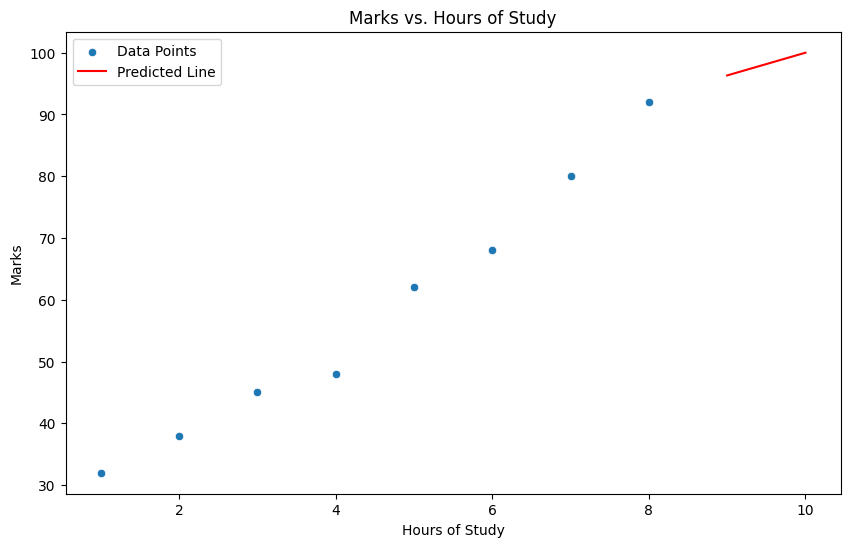

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Marks', data=df, label='Data Points')
plt.plot(new_hours, final_predictions, color='red', label='Predicted Line')
plt.title('Marks vs. Hours of Study')
plt.xlabel('Hours of Study')
plt.ylabel('Marks')
plt.legend()
plt.show()

###### NOTE : SHOULD BE ABLE TO PREDICT IF NEW VALUES ARE TO BE PROVIDED OUTSIDE THE DATA FRAME